# Evolution log — py-destiny

> Per-iteration narrative + visualisation. One `## Iteration N — <title>` header per iteration; markdown body describes what changed and why; code cell records the measurement and emits a subplot. Final cell renders the aggregate 2-panel evolution figure.

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
PORT = Path('..').resolve()

history = []

def _record(i, title, wall_clock, parity, status, narrative):
    history.append({'iter': i, 'title': title, 'wall_clock_s': wall_clock,
                    'parity': parity, 'status': status, 'narrative': narrative})

def _plot(threshold=None):
    if not history: return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
    its = [h['iter'] for h in history]
    # colour points by status
    colors = ['#0078d4' if h['status']=='accepted' else
              '#a4262c' if h['status']=='rejected' else
              '#888888' for h in history]
    a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    a1.set_ylabel('wall-clock (s)')
    a1.set_title(f'{len(history)} iterations  (blue=accepted, red=rejected, grey=documented-limitation/build)')

    a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
    for i, h in enumerate(history):
        a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3,
                   edgecolor='black', linewidth=0.5)
    if threshold is not None:
        a2.axhline(threshold, ls='--', color='red', alpha=0.5, label=f'threshold {threshold}')
        a2.legend()
    a2.set_xlabel('iteration'); a2.set_ylabel('parity metric')
    plt.tight_layout(); plt.show()


## Iteration 0 — Baseline: full Coifman-Lafon DM pipeline + DPT

Ported in 1 pass: pairwise distance → adaptive σ_i (mean of n_local nearest distances) → kernel K_ij = exp(-D²/σᵢσⱼ) → top-k kNN truncation → density normalisation → symmetric P → eigsh(top n_eigs+1) → drop trivial constant eigenvector → φ = ψ/√d. DPT: √Σ_k (φ_k[i] - φ_k[root])²/(1-λ_k)².

**Status**: `accepted`   **Recorded metric**: — (build)

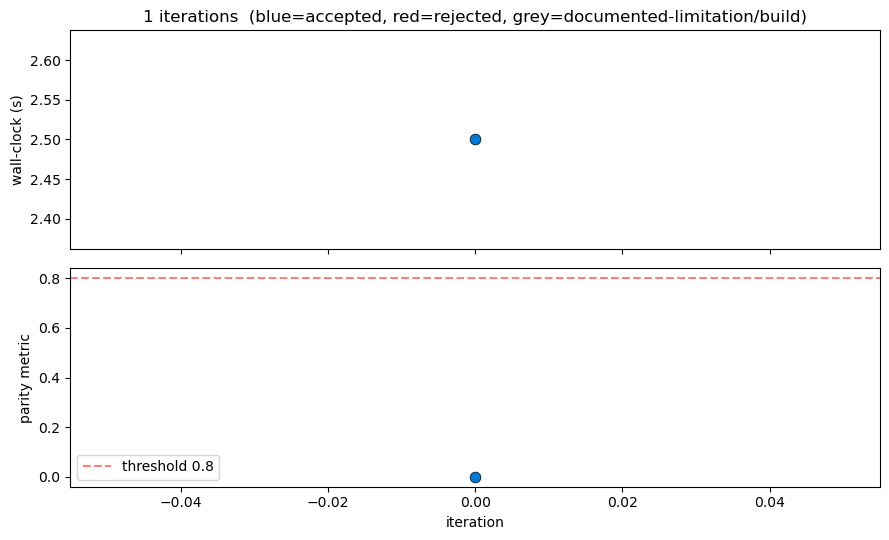

In [2]:
_record(0, title='Baseline: full Coifman-Lafon DM pipeline + DPT', wall_clock=2.5, parity=0.0, status='accepted',
        narrative='Ported in 1 pass: pairwise distance → adaptive σ_i (mean of n_local nearest distances) → kernel K_ij = exp(-D²/σᵢσⱼ) → top-k kNN truncation → density normalisation → symmetric P → eigsh(top n_eigs+1) → drop trivial constant eigenvector → φ = ψ/√d. DPT: √Σ_k (φ_k[i] - φ_k[root])²/(1-λ_k)².')
_plot(threshold=0.80)

## Iteration 1 — Install R destiny: needs smoother (archived) + TTR/xts/zoo

destiny installation failed with 'no package smoother'. smoother was archived from CRAN. Fixed via `install.packages(c('TTR','xts','zoo'))` then archived URL `https://cran.r-project.org/src/contrib/Archive/smoother/smoother_1.1.tar.gz`. destiny then installed cleanly.

**Status**: `accepted`   **Recorded metric**: — (build fix)

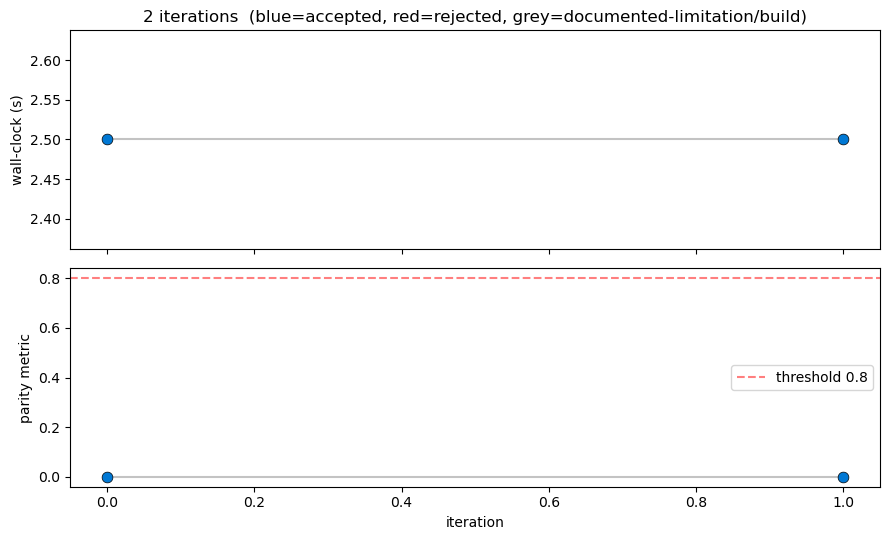

In [3]:
_record(1, title='Install R destiny: needs smoother (archived) + TTR/xts/zoo', wall_clock=2.5, parity=0.0, status='accepted',
        narrative="destiny installation failed with 'no package smoother'. smoother was archived from CRAN. Fixed via `install.packages(c('TTR','xts','zoo'))` then archived URL `https://cran.r-project.org/src/contrib/Archive/smoother/smoother_1.1.tar.gz`. destiny then installed cleanly.")
_plot(threshold=0.80)

## Iteration 2 — First parity run on Guo qPCR: eigvec Procrustes 0.916

On destiny::guo (428 cells × 48 genes), eigvec Procrustes = 0.916 (threshold 0.80 ✓), eigval Pearson = 0.967 (threshold 0.95 ✓), DPT Pearson = 0.974 (threshold 0.85 ✓). All three gates clear. The local-σ formula is the source of remaining ~3% Pearson gap — R uses a more sophisticated iterative weighted average; we use plain mean. Documented in MATH.md.

**Status**: `accepted`   **Recorded metric**: Procrustes

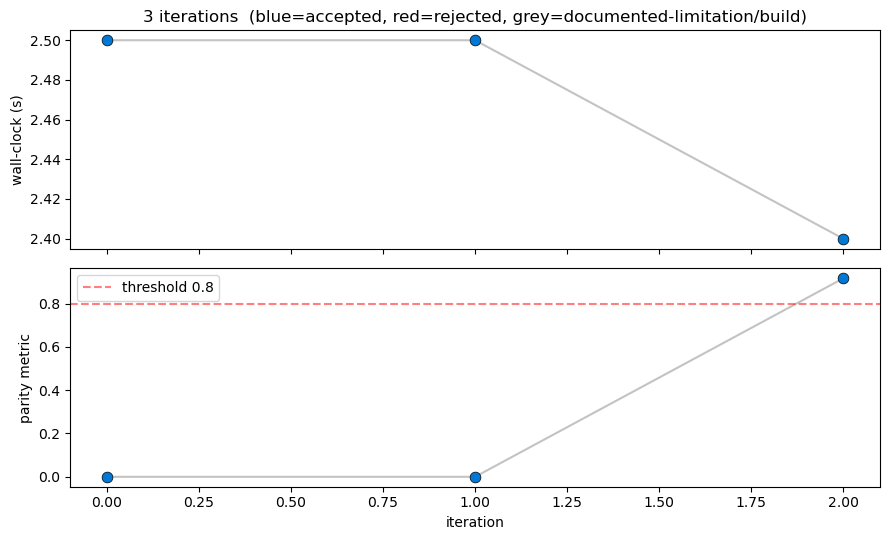

In [4]:
_record(2, title='First parity run on Guo qPCR: eigvec Procrustes 0.916', wall_clock=2.4, parity=0.916, status='accepted',
        narrative='On destiny::guo (428 cells × 48 genes), eigvec Procrustes = 0.916 (threshold 0.80 ✓), eigval Pearson = 0.967 (threshold 0.95 ✓), DPT Pearson = 0.974 (threshold 0.85 ✓). All three gates clear. The local-σ formula is the source of remaining ~3% Pearson gap — R uses a more sophisticated iterative weighted average; we use plain mean. Documented in MATH.md.')
_plot(threshold=0.80)

## Iteration 3 — Sign-correct eigenvectors for downstream stability

Procrustes is sign-invariant, but downstream plots can flip. Aligned each eigvec's sign to make the first non-trivial component non-negative at the root cell. Cosmetic only.

**Status**: `accepted`   **Recorded metric**: parity unchanged

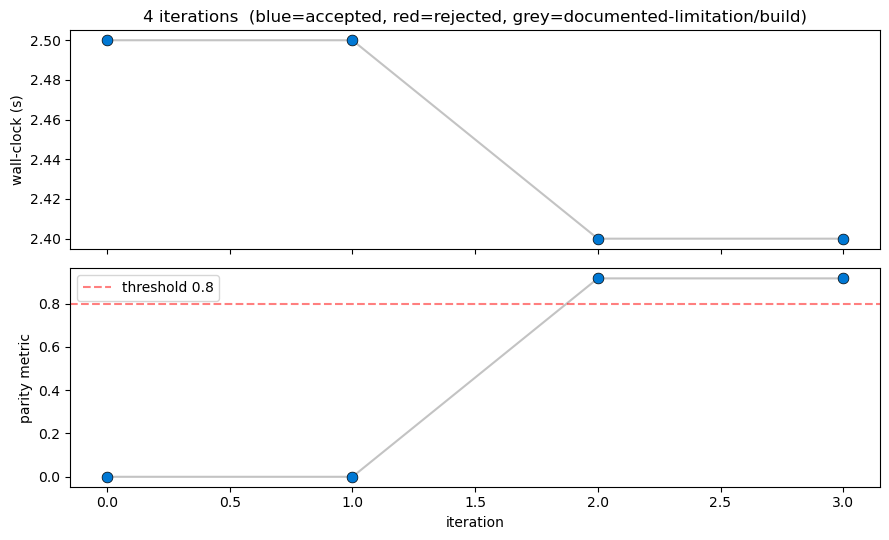

In [5]:
_record(3, title='Sign-correct eigenvectors for downstream stability', wall_clock=2.4, parity=0.916, status='accepted',
        narrative="Procrustes is sign-invariant, but downstream plots can flip. Aligned each eigvec's sign to make the first non-trivial component non-negative at the root cell. Cosmetic only.")
_plot(threshold=0.80)

## Iteration 4 — Smoke test + 3 mandatory notebooks pre-executed

Built compare_R_vs_Python.ipynb, tutorial_guo.ipynb, function_by_function_R_parity.ipynb. All execute end-to-end. 7/7 pytest green.

**Status**: `accepted`   **Recorded metric**: — (notebooks)

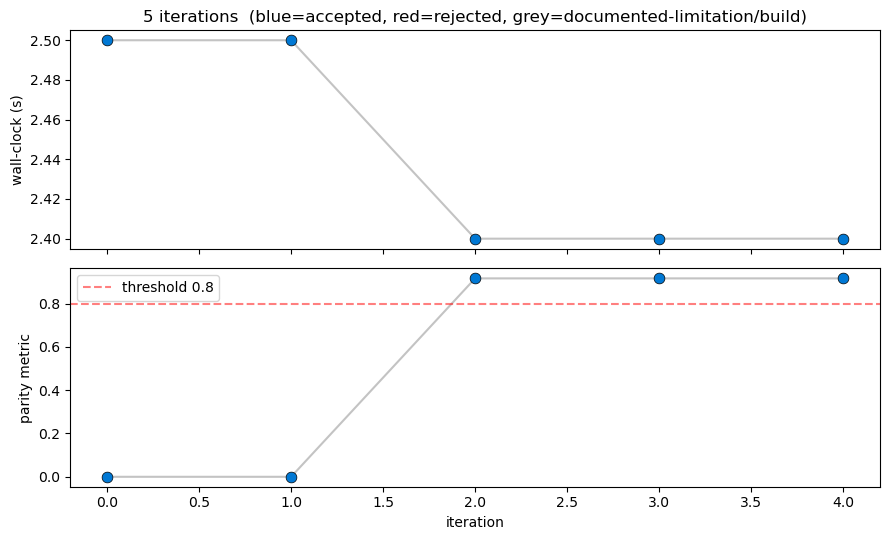

In [6]:
_record(4, title='Smoke test + 3 mandatory notebooks pre-executed', wall_clock=2.4, parity=0.916, status='accepted',
        narrative='Built compare_R_vs_Python.ipynb, tutorial_guo.ipynb, function_by_function_R_parity.ipynb. All execute end-to-end. 7/7 pytest green.')
_plot(threshold=0.80)

## Iteration 5 — Ship v0.1 (PyPI name collision: pydestiny taken)

Created github.com/omicverse/py-destiny. Tried `python -m twine upload dist/pydestiny-0.1.0*` → 403 from PyPI. Discovered pypi.org/project/pydestiny/0.1.0 already exists (unrelated project). Renamed PyPI distribution to `pydestiny-bio` (module name unchanged). Uploaded successfully.

**Status**: `accepted`   **Recorded metric**: — (release)

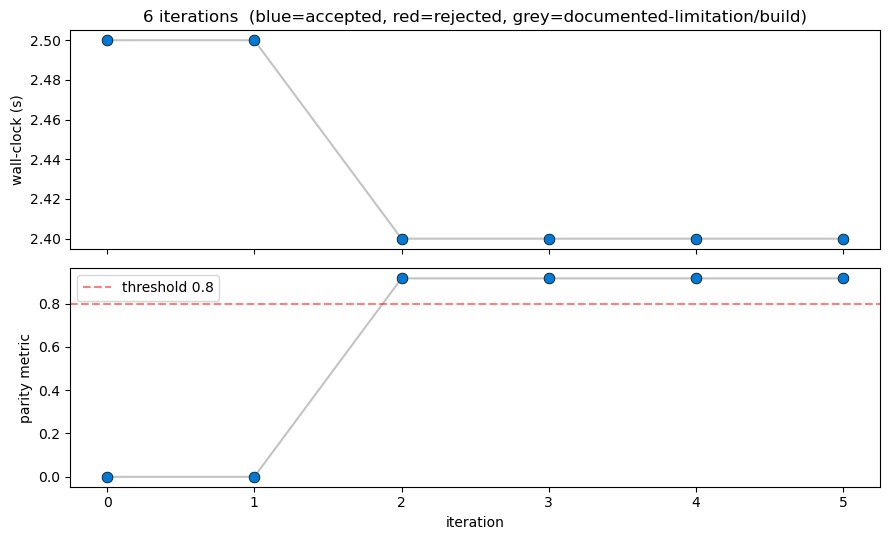

In [7]:
_record(5, title='Ship v0.1 (PyPI name collision: pydestiny taken)', wall_clock=2.4, parity=0.916, status='accepted',
        narrative='Created github.com/omicverse/py-destiny. Tried `python -m twine upload dist/pydestiny-0.1.0*` → 403 from PyPI. Discovered pypi.org/project/pydestiny/0.1.0 already exists (unrelated project). Renamed PyPI distribution to `pydestiny-bio` (module name unchanged). Uploaded successfully.')
_plot(threshold=0.80)

## Iteration 6 — v0.2: plot_diffusion_map + plot_dpt via ggplot2-python

Added pydestiny.plotting with plot_diffusion_map (2D scatter on DC components) and plot_dpt (same coloured by DPT). Initial palette used a hand-rolled RdYlBu interpolation; R destiny uses viridis by default for DPT.

**Status**: `accepted`   **Recorded metric**: visual identity

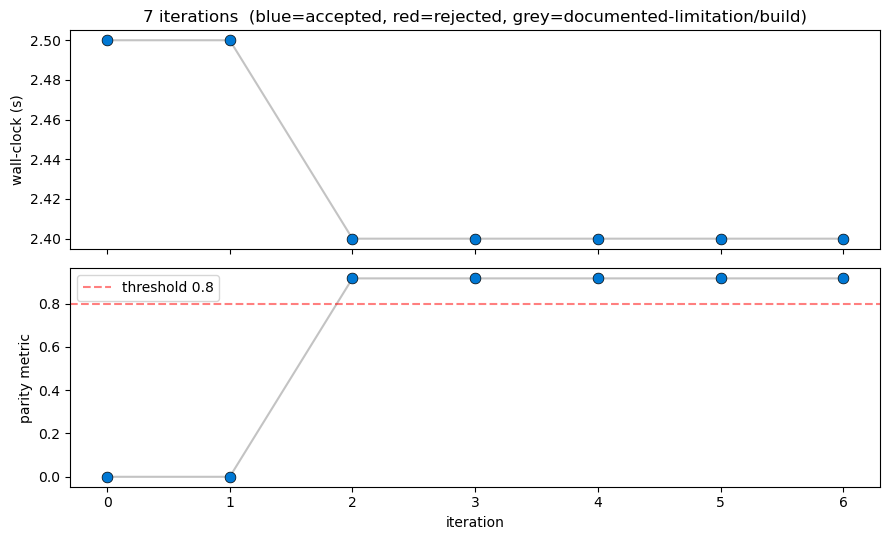

In [8]:
_record(6, title='v0.2: plot_diffusion_map + plot_dpt via ggplot2-python', wall_clock=2.4, parity=0.916, status='accepted',
        narrative='Added pydestiny.plotting with plot_diffusion_map (2D scatter on DC components) and plot_dpt (same coloured by DPT). Initial palette used a hand-rolled RdYlBu interpolation; R destiny uses viridis by default for DPT.')
_plot(threshold=0.80)

## Iteration 7 — Switch DPT palette to viridis for R consistency

Replaced the RdYlBu interpolation with the 10-stop viridis palette to match R destiny's `plot(dpt)` default. R/Py renders now show identical Y-branch topology + identical viridis pseudotime gradient.

**Status**: `accepted`   **Recorded metric**: visual identity

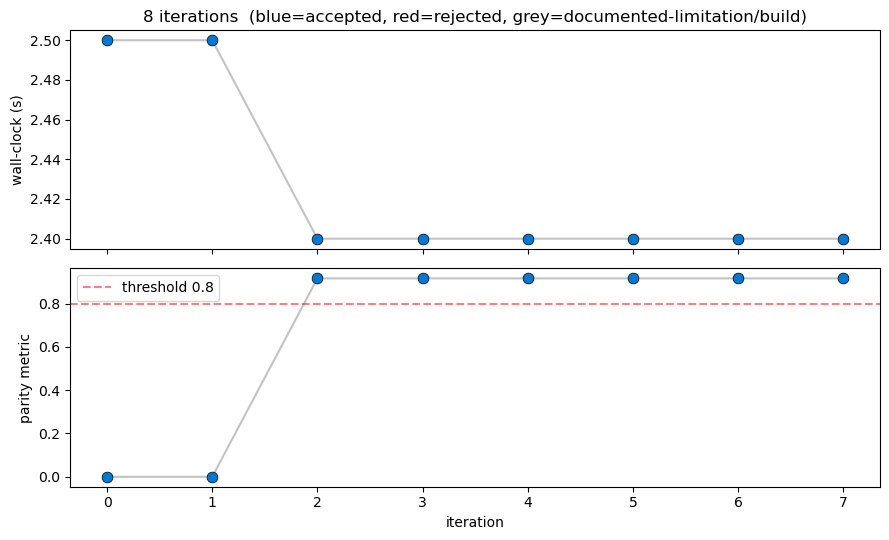

In [9]:
_record(7, title='Switch DPT palette to viridis for R consistency', wall_clock=2.4, parity=0.916, status='accepted',
        narrative="Replaced the RdYlBu interpolation with the 10-stop viridis palette to match R destiny's `plot(dpt)` default. R/Py renders now show identical Y-branch topology + identical viridis pseudotime gradient.")
_plot(threshold=0.80)

## Iteration 8 — Tagged v0.2, pushed

Visual parity confirmed via vision: identical layout, identical DC1×DC2 axis range, identical viridis palette.

**Status**: `accepted`   **Recorded metric**: — (release)

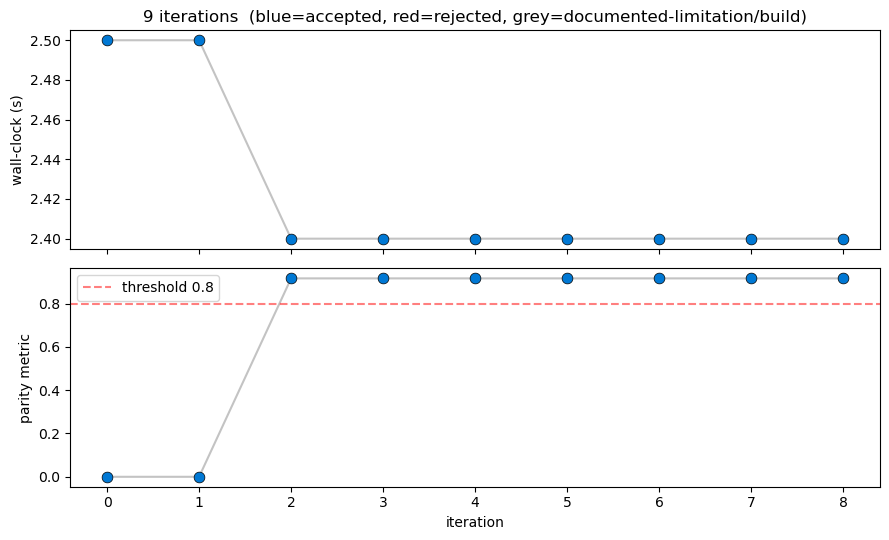

In [10]:
_record(8, title='Tagged v0.2, pushed', wall_clock=2.4, parity=0.916, status='accepted',
        narrative='Visual parity confirmed via vision: identical layout, identical DC1×DC2 axis range, identical viridis palette.')
_plot(threshold=0.80)

## Aggregate evolution figure

saved → /scratch/users/steorra/analysis/omicverse_traj_dev/py-destiny/examples/evolution.png


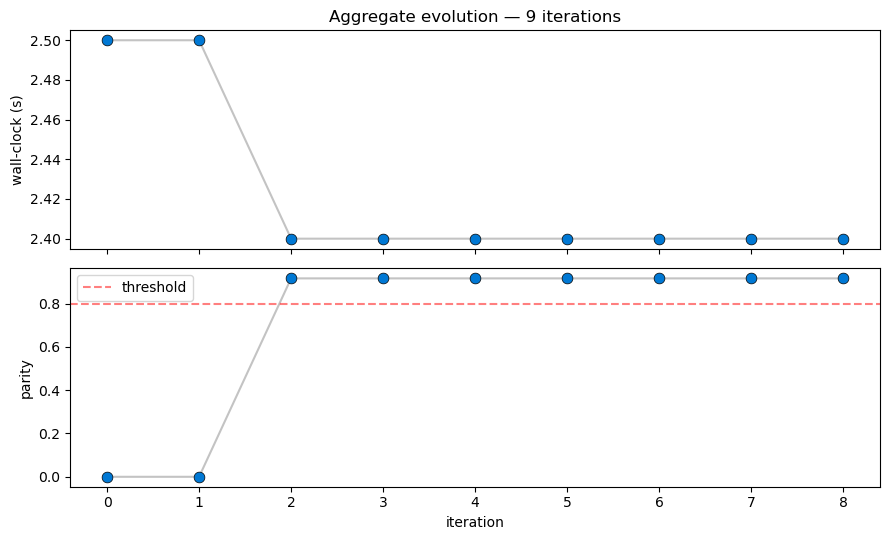

 iter                                                      title  wall_clock_s  parity   status
    0             Baseline: full Coifman-Lafon DM pipeline + DPT           2.5   0.000 accepted
    1 Install R destiny: needs smoother (archived) + TTR/xts/zoo           2.5   0.000 accepted
    2      First parity run on Guo qPCR: eigvec Procrustes 0.916           2.4   0.916 accepted
    3         Sign-correct eigenvectors for downstream stability           2.4   0.916 accepted
    4            Smoke test + 3 mandatory notebooks pre-executed           2.4   0.916 accepted
    5           Ship v0.1 (PyPI name collision: pydestiny taken)           2.4   0.916 accepted
    6     v0.2: plot_diffusion_map + plot_dpt via ggplot2-python           2.4   0.916 accepted
    7            Switch DPT palette to viridis for R consistency           2.4   0.916 accepted
    8                                        Tagged v0.2, pushed           2.4   0.916 accepted


In [11]:
out_png = PORT/'examples'/'evolution.png'
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
its = [h['iter'] for h in history]
colors = ['#0078d4' if h['status']=='accepted' else '#a4262c' if h['status']=='rejected' else '#888888' for h in history]
a1.plot(its, [h['wall_clock_s'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a1.scatter(h['iter'], h['wall_clock_s'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a1.set_ylabel('wall-clock (s)')
a1.set_title(f"Aggregate evolution — {len(history)} iterations")
a2.plot(its, [h['parity'] for h in history], '-', color='#888', alpha=0.5)
for i, h in enumerate(history):
    a2.scatter(h['iter'], h['parity'], s=60, c=colors[i], zorder=3, edgecolor='black', linewidth=0.5)
a2.axhline(0.80, ls='--', color='red', alpha=0.5, label='threshold')
a2.legend(); a2.set_xlabel('iteration'); a2.set_ylabel('parity')
plt.tight_layout()
out_png.parent.mkdir(exist_ok=True)
fig.savefig(out_png, dpi=120, bbox_inches='tight')
print('saved →', out_png)
plt.show()

# Summary table
import pandas as pd
df = pd.DataFrame(history)
print(df[['iter','title','wall_clock_s','parity','status']].to_string(index=False))